# Analysis: 20251104

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cdk.analysis.cytosol import platereader as pr

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
data_file = "./20251104-cytation3-pure-timecourse-gfp-NucleusPURE_deGFP-biotek-cdk.txt"
platemap_file = "./20251104-NucleusPURE-deGFP-platemap.csv"

data, platemap = pr.load_platereader_data(data_file, platemap_file)

# Basic Analysis

## Curves
Curves of RFU over time, by named sample.

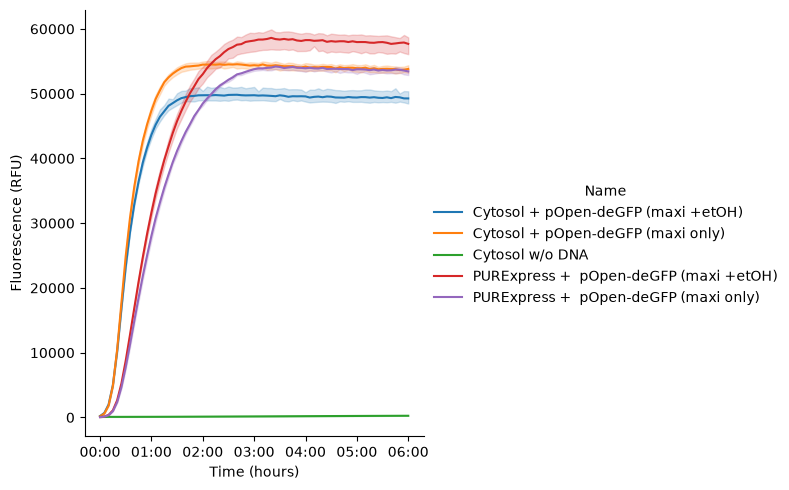

In [4]:
#| label: fig:kinetics-exp1

K=pr.plot_curves(data)
K.savefig('Kinetics')

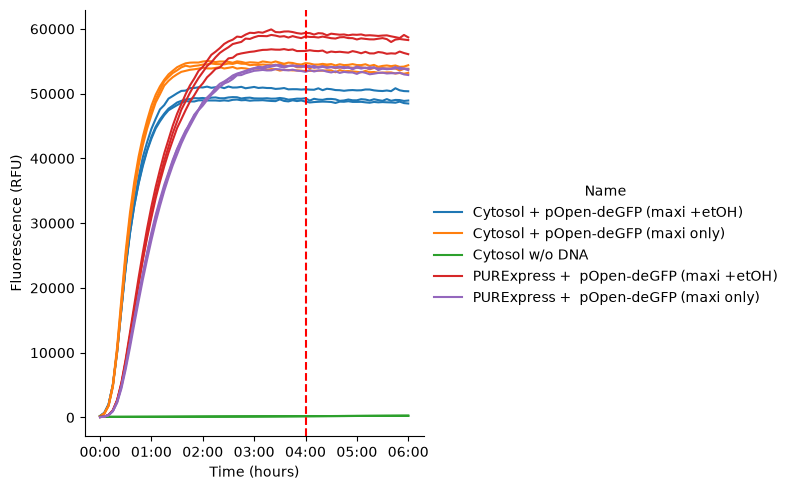

In [5]:
K2=pr.plot_curves(data, units="Well", estimator=None)
K2.axes.flatten()[0].axvline(pd.to_timedelta("04:00:00"), c="red", ls="--")
K2.savefig('Kinetics2')

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

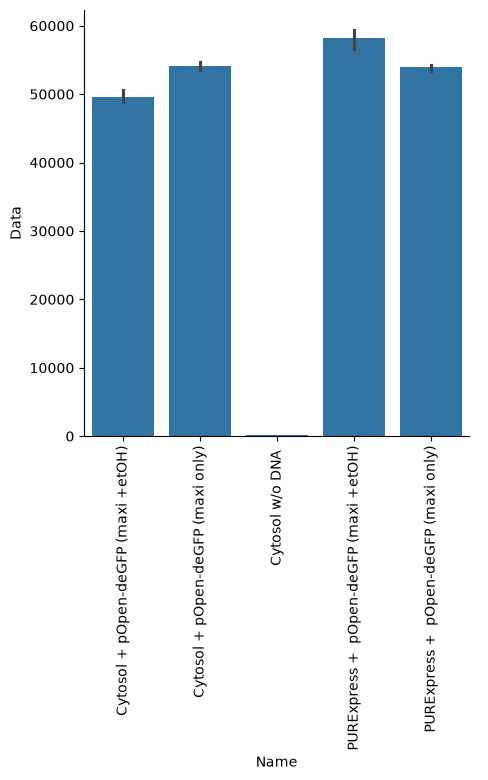

In [6]:
#| label: fig:endpoint-exp1

g = sns.catplot(
    data=data[data["Time"] == "04:00:00"],
    x="Name",
    y="Data",
    kind="bar"
)

g.set_xticklabels(rotation=90)
g.savefig('Steadystate')

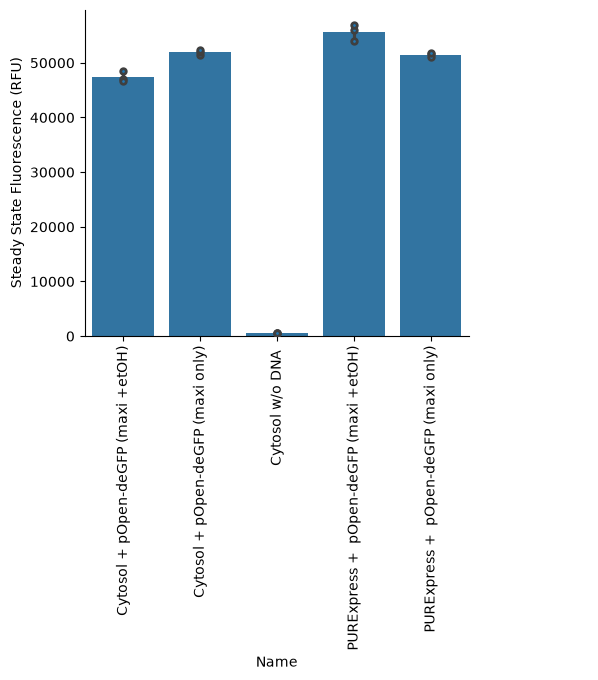

In [7]:
S= pr.plot_steadystate(data)
S.savefig('endpoint')

## Kinetics
These functions calculate key kinetic parameters of the time series.

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x30c13e850>,
                                                                   Velocity  \
                                                                       Time   
 Name                                   Read                                  
 Cytosol + pOpen-deGFP (maxi +etOH)     GFP-F-G35 0 days 00:32:16.243958277   
 Cytosol + pOpen-deGFP (maxi only)      GFP-F-G35 0 days 00:32:40.052704496   
 Cytosol w/o DNA                        GFP-F-G35 0 days 03:29:05.730264123   
 PURExpress +  pOpen-deGFP (maxi +etOH) GFP-F-G35 0 days 00:54:38.904421908   
 PURExpress +  pOpen-deGFP (maxi only)  GFP-F-G35 0 days 00:56:11.920378355   
 
                                                                     \
                                                      Data      Max   
 Name                                   Read                          
 Cytosol + pOpen-deGFP (maxi +etOH)     GFP-F-G35 24947.79 69624.69   
 Cytosol + pOpen-deGFP (maxi only)  

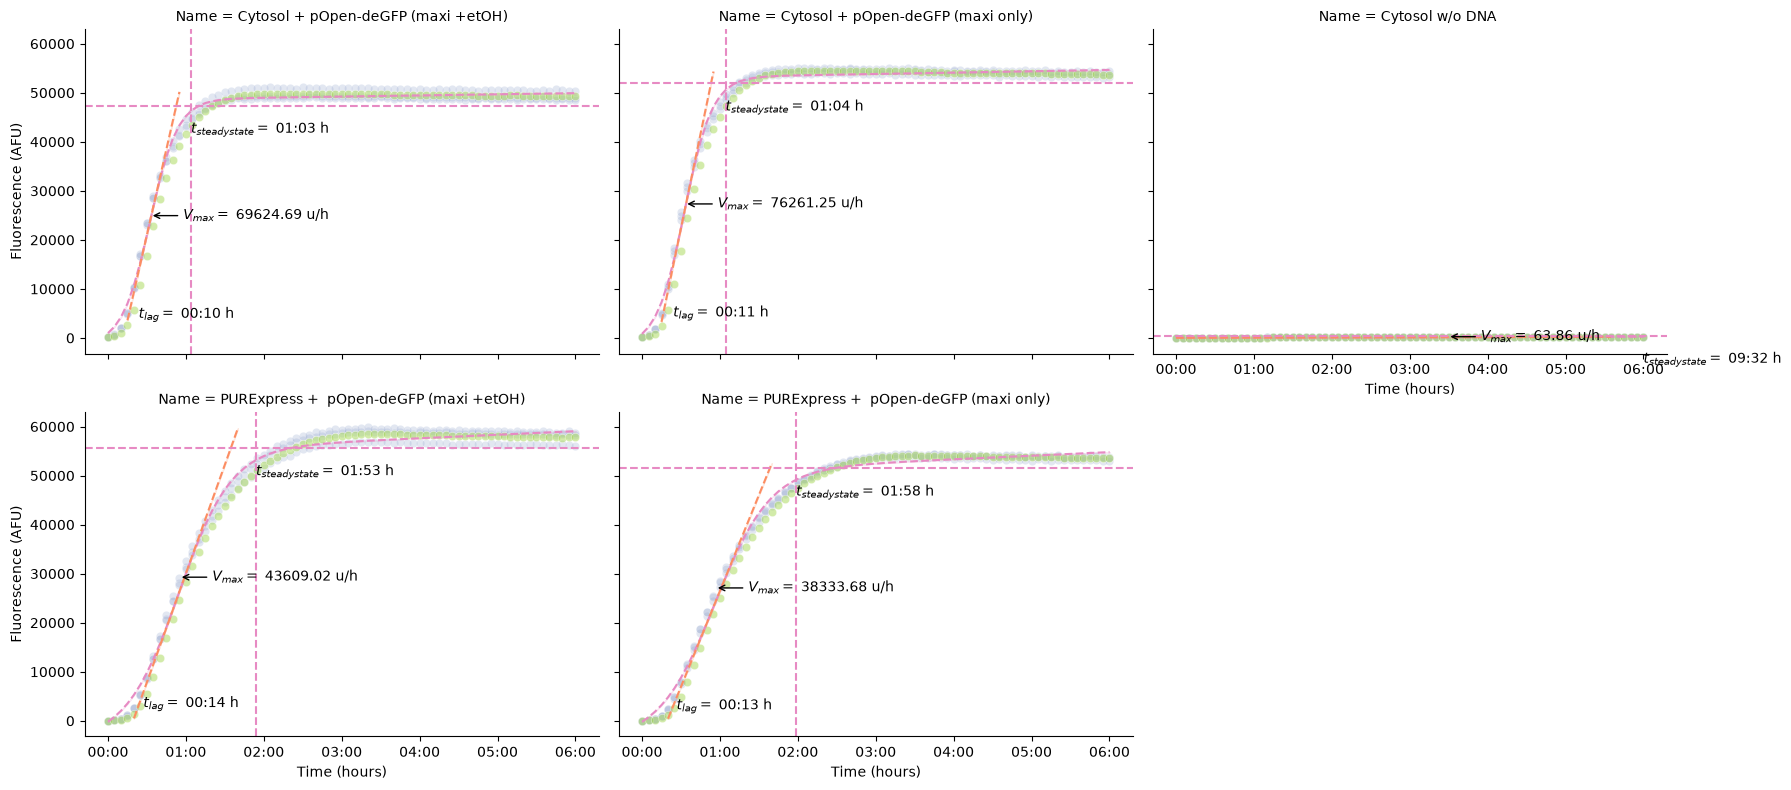

In [8]:
pr.plot_kinetics(data)

We can also calculate the kinetics and display the parameters as a table.

In [9]:
pr.kinetic_analysis(data)

Velocity  \
                                                                           Time   
Name                                   Read      Well                             
Cytosol + pOpen-deGFP (maxi +etOH)     GFP-F-G35 B3   0 days 00:32:37.225767667   
                                                 B5   0 days 00:32:15.496008208   
                                                 B7   0 days 00:31:56.010098956   
Cytosol + pOpen-deGFP (maxi only)      GFP-F-G35 D3   0 days 00:33:04.006279706   
                                                 D5   0 days 00:32:36.425606157   
                                                 D7   0 days 00:32:19.726227625   
Cytosol w/o DNA                        GFP-F-G35 F3   0 days 03:30:36.735354198   
                                                 F5   0 days 03:27:56.518774167   
                                                 F7   0 days 03:28:43.936664005   
PURExpress +  pOpen-deGFP (maxi +etOH) GFP-F-G35 H3   0 days 00:55:17.138591090   
                                                 H5   0 days 00:54:21.428044556   
                                                 H7   0 days 00:54:18.146630080   
PURExpress +  pOpen-deGFP (maxi only)  GFP-F-G35 J3   0 days 00:57:08.479200175   
                                                 J5   0 days 00:55:26.769204076   
                                                 J7   0 days 00:56:00.512730816   

                                                                         \
                                                          Data      Max   
Name                                   Read      Well                     
Cytosol + pOpen-deGFP (maxi +etOH)     GFP-F-G35 B3   25553.25 70819.58   
                                                 B5   24732.31 69253.24   
                                                 B7   24557.81 68801.24   
Cytosol + pOpen-deGFP (maxi only)      GFP-F-G35 D3   27074.47 74864.13   
                                                 D5   27399.86 76169.81   
                                                 D7   27521.37 77749.81   
Cytosol w/o DNA                        GFP-F-G35 F3     261.17    63.42   
                                                 F5     263.45    64.42   
                                                 F7     262.45    63.75   
PURExpress +  pOpen-deGFP (maxi +etOH) GFP-F-G35 H3   29499.23 43401.54   
                                                 H5   29940.05 44882.77   
                                                 H7   28417.27 42542.74   
PURExpress +  pOpen-deGFP (maxi only)  GFP-F-G35 J3   27193.57 37615.41   
                                                 J5   26872.97 39100.96   
                                                 J7   27215.59 38284.65   

                                                                              Lag  \
                                                                             Time   
Name                                   Read      Well                               
Cytosol + pOpen-deGFP (maxi +etOH)     GFP-F-G35 B3     0 days 00:10:58.267443190   
                                                 B5     0 days 00:10:49.832930532   
                                                 B7     0 days 00:10:31.031606427   
Cytosol + pOpen-deGFP (maxi only)      GFP-F-G35 D3     0 days 00:11:22.073303367   
                                                 D5     0 days 00:11:01.431007332   
                                                 D7     0 days 00:11:05.421983823   
Cytosol w/o DNA                        GFP-F-G35 F3   -1 days +23:23:30.619698357   
                                                 F5   -1 days +23:22:33.484001124   
                                                 F7   -1 days +23:21:42.772361642   
PURExpress +  pOpen-deGFP (maxi +etOH) GFP-F-G35 H3     0 days 00:14:30.284811326   
                                                 H5     0 days 00:14:19.968003769   
                                   